<a href="https://colab.research.google.com/github/spandana1320/B19_1320/blob/main/sesdgrpcode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

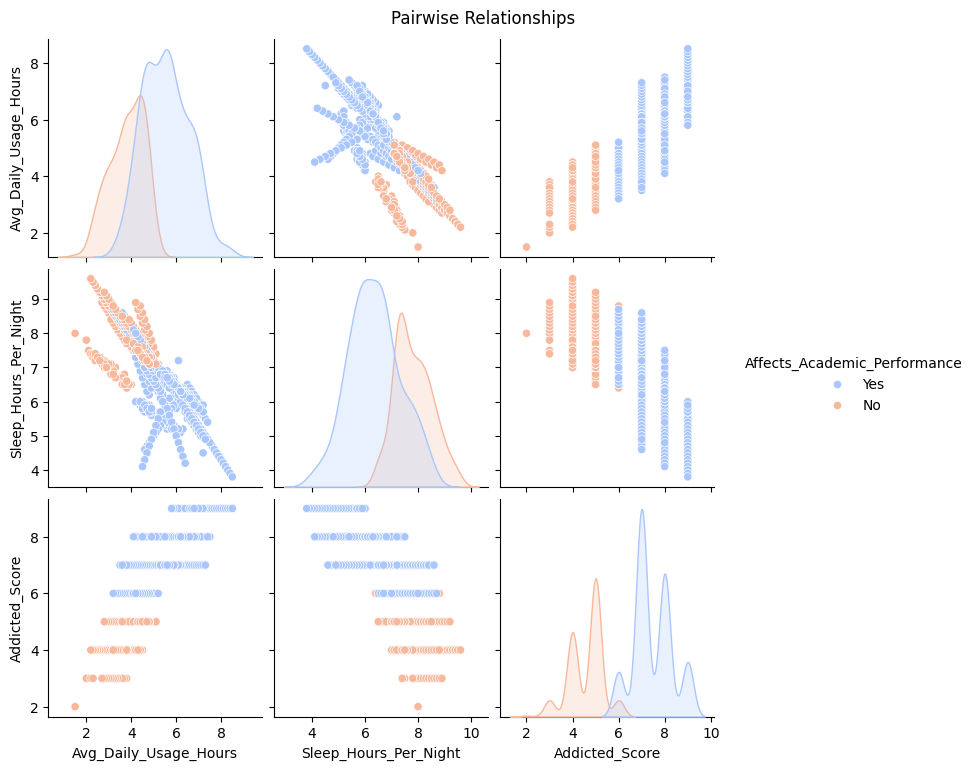

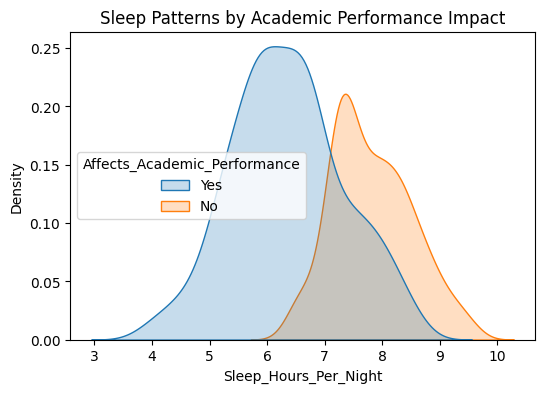

Baseline Accuracy (majority class): 64.26 %

Logistic Regression Results:
Accuracy: 100.0 %
Balanced Accuracy: 100.0 %
F1-score: 100.0 %
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       1.00      1.00      1.00        87

    accuracy                           1.00       141
   macro avg       1.00      1.00      1.00       141
weighted avg       1.00      1.00      1.00       141

Cross-validation Accuracy: 99.72 %


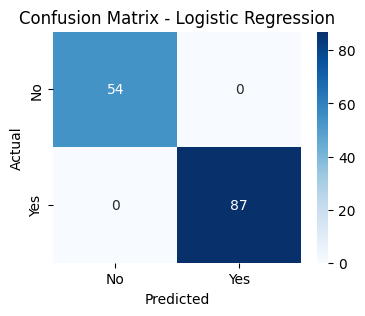

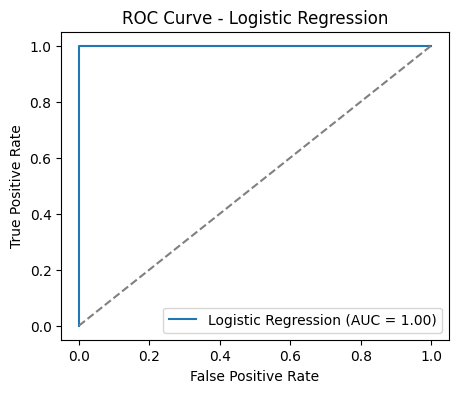

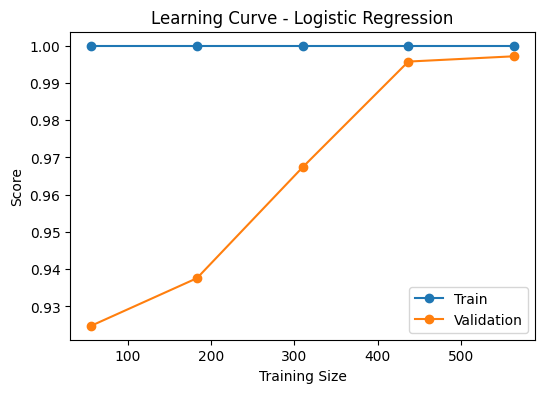


SVM (Linear) Results:
Accuracy: 100.0 %
Balanced Accuracy: 100.0 %
F1-score: 100.0 %
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       1.00      1.00      1.00        87

    accuracy                           1.00       141
   macro avg       1.00      1.00      1.00       141
weighted avg       1.00      1.00      1.00       141

Cross-validation Accuracy: 99.57 %


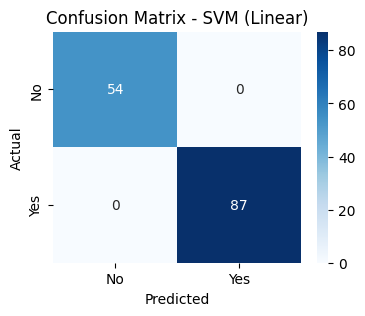

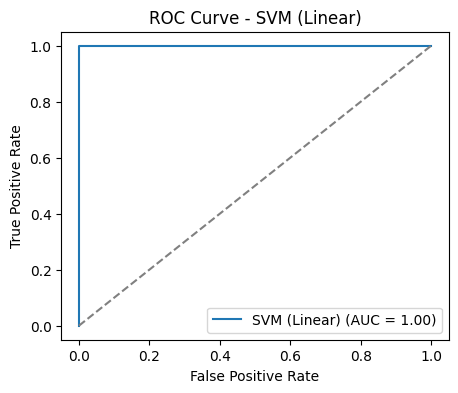

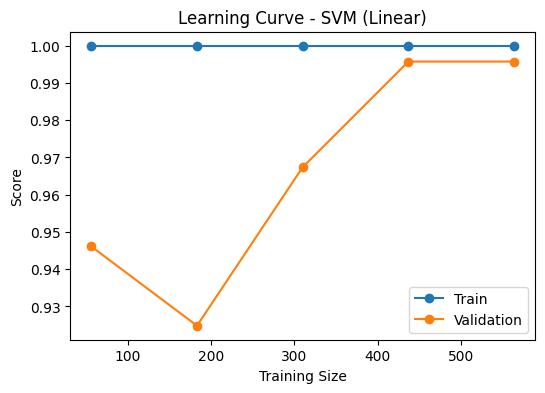


Random Forest Results:
Accuracy: 100.0 %
Balanced Accuracy: 100.0 %
F1-score: 100.0 %
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       1.00      1.00      1.00        87

    accuracy                           1.00       141
   macro avg       1.00      1.00      1.00       141
weighted avg       1.00      1.00      1.00       141

Cross-validation Accuracy: 100.0 %


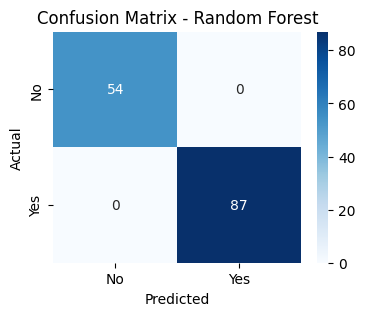

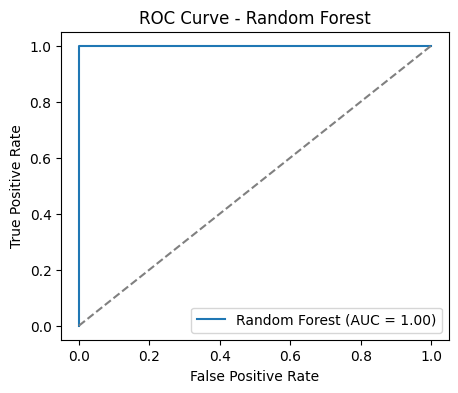

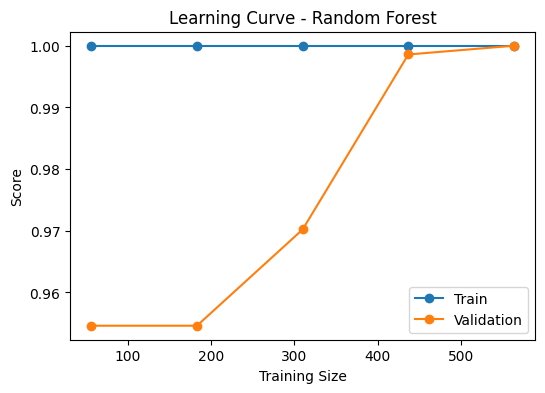

/tmp/ipython-input-502554782.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")


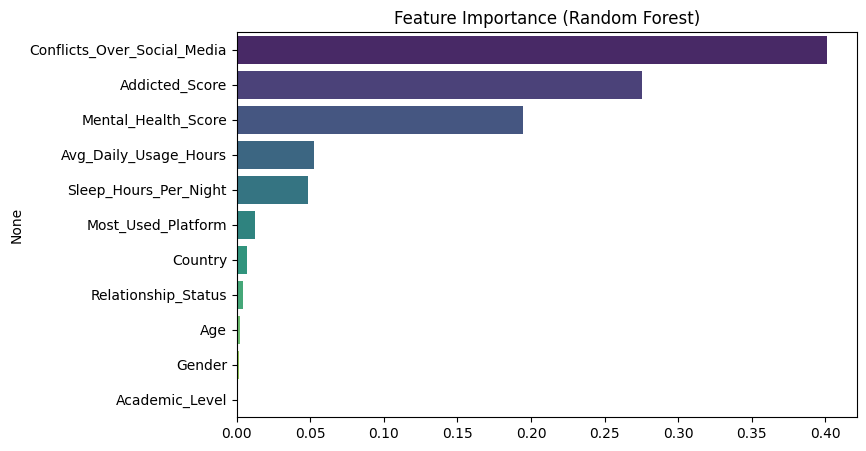

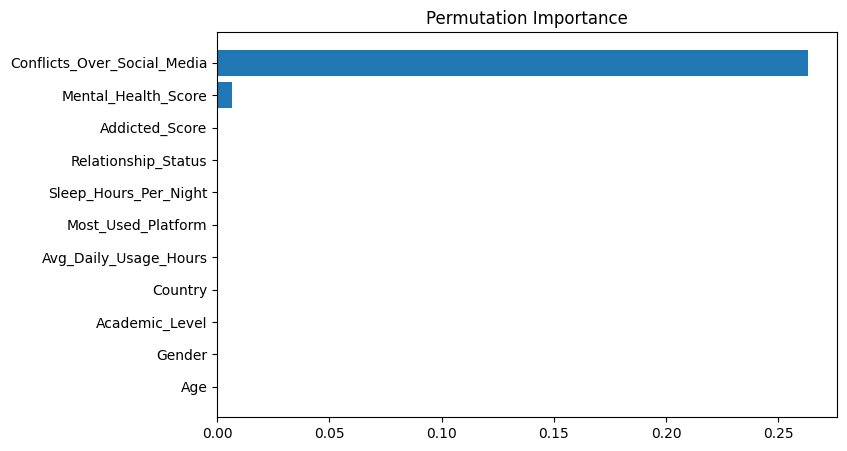

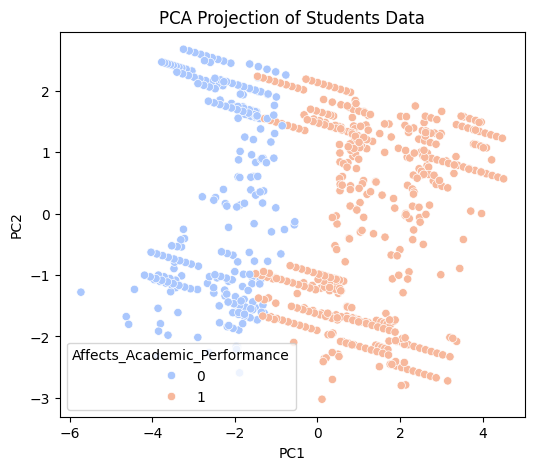

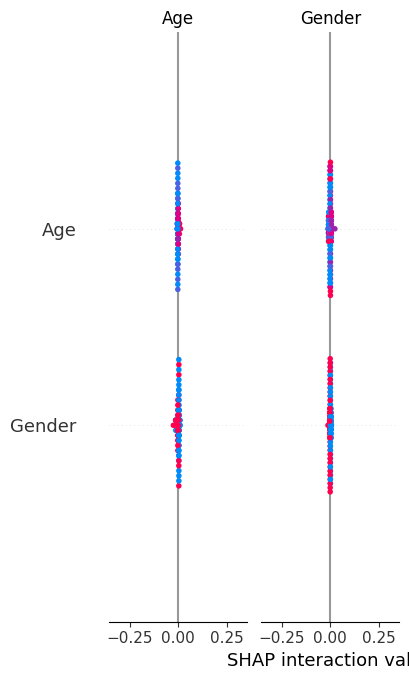

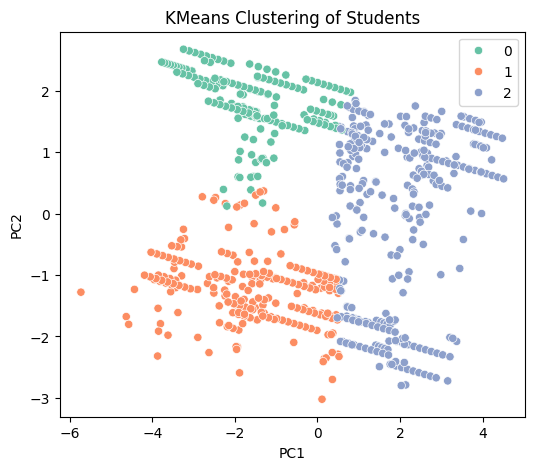

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, roc_curve, f1_score, balanced_accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans
import shap
import numpy as np

# ===================== Load Dataset =====================
df = pd.read_csv("/content/Students Social Media Addiction.csv")

# ===================== EDA =====================
sns.pairplot(df[["Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night", "Addicted_Score", "Affects_Academic_Performance"]],
             hue="Affects_Academic_Performance", palette="coolwarm")
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()

plt.figure(figsize=(6,4))
sns.kdeplot(data=df, x="Sleep_Hours_Per_Night", hue="Affects_Academic_Performance", fill=True)
plt.title("Sleep Patterns by Academic Performance Impact")
plt.show()

# ===================== Machine Learning =====================
# NOVELTY: Baseline Accuracy (benchmark against majority class)
baseline = df["Affects_Academic_Performance"].value_counts(normalize=True).max()
print("Baseline Accuracy (majority class):", round(baseline * 100, 2), "%")

y = df["Affects_Academic_Performance"].map({"Yes": 1, "No": 0})
X = df.drop(columns=["Student_ID", "Affects_Academic_Performance"])

# Encode categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns
encoder = LabelEncoder()
for col in categorical_cols:
    X[col] = encoder.fit_transform(X[col])

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Keep DataFrame version for SHAP & explainability
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM (Linear)": SVC(kernel="linear", probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Train & evaluate models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    print(f"\n{name} Results:")
    print("Accuracy:", round(acc * 100, 2), "%")
    print("Balanced Accuracy:", round(bal_acc * 100, 2), "%")   # NOVELTY: Balanced accuracy for imbalanced data
    print("F1-score:", round(f1 * 100, 2), "%")                 # NOVELTY: F1-score for imbalanced data
    print(classification_report(y_test, y_pred))

    # NOVELTY: Cross-validation for robust evaluation
    scores = cross_val_score(model, X_scaled, y, cv=5)
    print("Cross-validation Accuracy:", round(scores.mean() * 100, 2), "%")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # NOVELTY: ROC Curve & AUC (goes beyond accuracy)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")
    plt.plot([0,1],[0,1],'--',color='gray')
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

    # NOVELTY: Learning Curve (detects overfitting/underfitting)
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_scaled, y, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1,1,5)
    )
    plt.figure(figsize=(6,4))
    plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label="Train")
    plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label="Validation")
    plt.title(f"Learning Curve - {name}")
    plt.xlabel("Training Size")
    plt.ylabel("Score")
    plt.legend()
    plt.show()

# ===================== Feature Importance =====================
# NOVELTY: Feature importance from Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,5))
sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")
plt.title("Feature Importance (Random Forest)")
plt.show()

# NOVELTY: Permutation Importance (model-agnostic, robust)
perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)
sorted_idx = perm.importances_mean.argsort()
plt.figure(figsize=(8,5))
plt.barh(X.columns[sorted_idx], perm.importances_mean[sorted_idx])
plt.title("Permutation Importance")
plt.show()

# ===================== PCA Visualization =====================
# NOVELTY: PCA for dimensionality reduction & visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(6,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette="coolwarm")
plt.title("PCA Projection of Students Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# ===================== SHAP Explainability =====================
# NOVELTY: SHAP values to interpret model predictions
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_df)

# NOVELTY: SHAP summary plot shows global feature importance with impact
shap.summary_plot(shap_values, X_test_df, feature_names=X.columns)

# ===================== Clustering Analysis =====================
# NOVELTY: KMeans clustering for unsupervised subgroup discovery
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
plt.figure(figsize=(6,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette="Set2")
plt.title("KMeans Clustering of Students")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


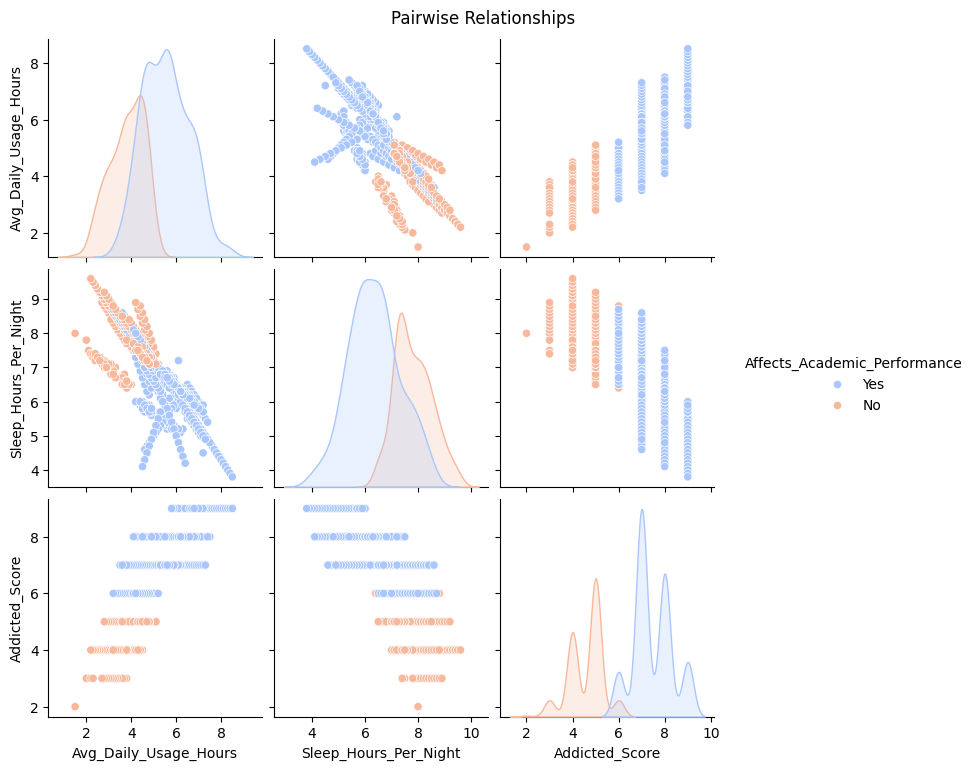

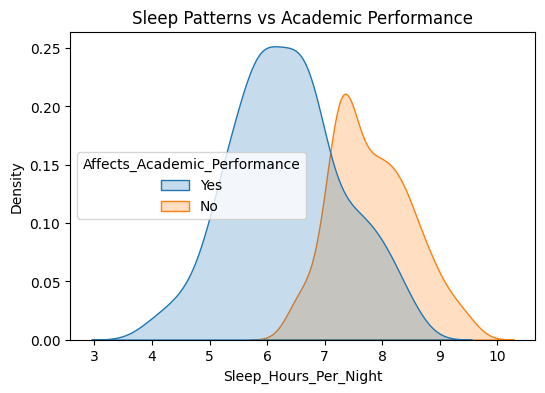


Logistic Regression (Noisy)
Accuracy: 89.36
Precision: 87.5
              precision    recall  f1-score   support

           0       0.93      0.78      0.85        54
           1       0.88      0.97      0.92        87

    accuracy                           0.89       141
   macro avg       0.90      0.87      0.88       141
weighted avg       0.90      0.89      0.89       141



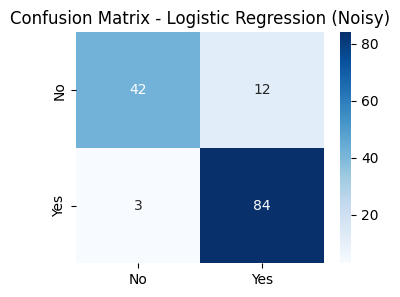

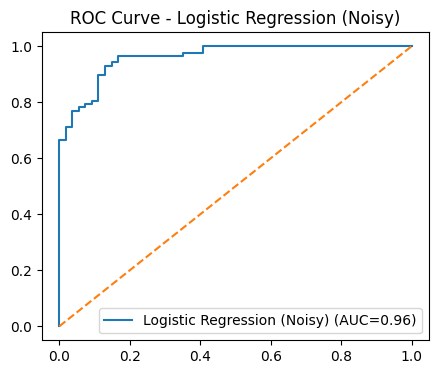

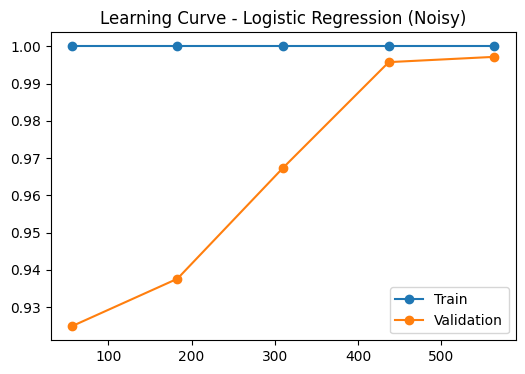


SVM (Noisy)
Accuracy: 94.33
Precision: 98.77
              precision    recall  f1-score   support

           0       0.88      0.98      0.93        54
           1       0.99      0.92      0.95        87

    accuracy                           0.94       141
   macro avg       0.94      0.95      0.94       141
weighted avg       0.95      0.94      0.94       141



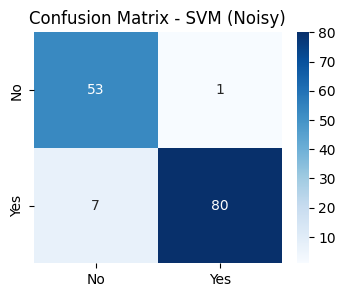

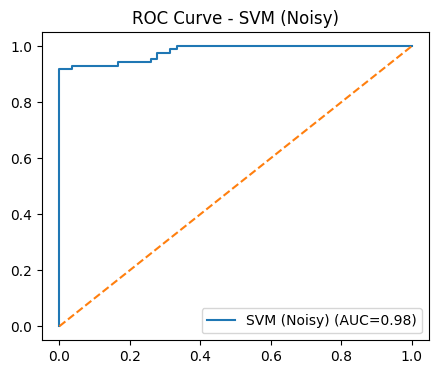

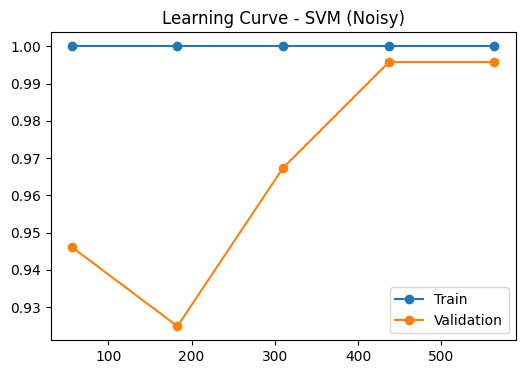


Random Forest (Noisy)
Accuracy: 84.4
Precision: 92.21
              precision    recall  f1-score   support

           0       0.75      0.89      0.81        54
           1       0.92      0.82      0.87        87

    accuracy                           0.84       141
   macro avg       0.84      0.85      0.84       141
weighted avg       0.86      0.84      0.85       141



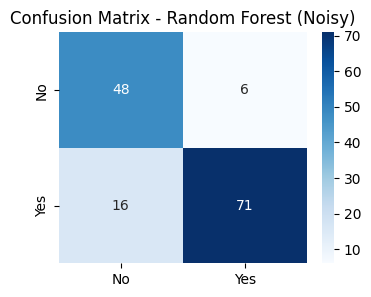

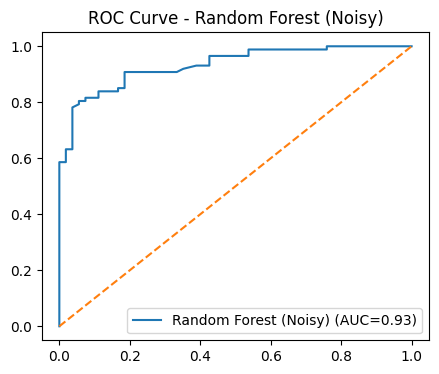

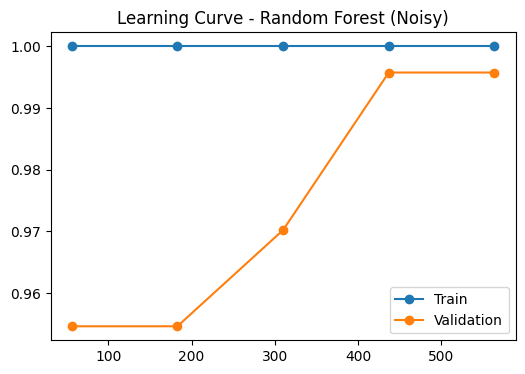

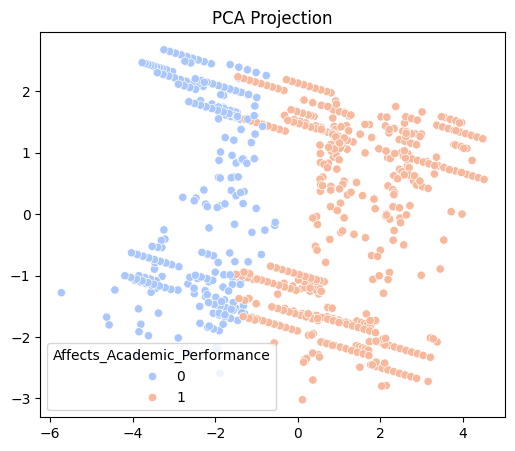

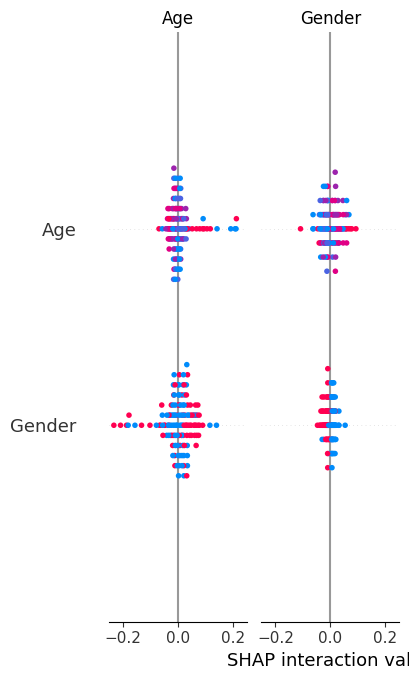

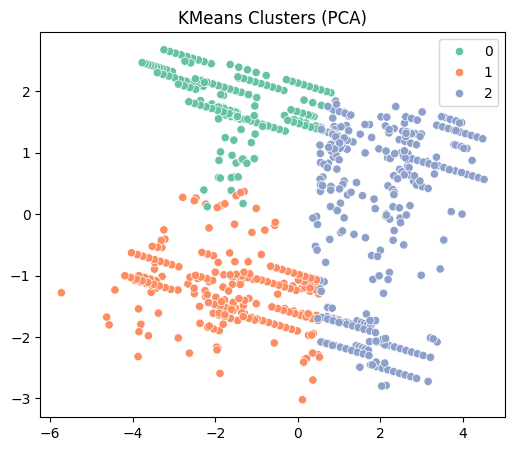


COMPARATIVE PERFORMANCE TABLE

                         Model  Accuracy  Precision  Recall  F1 Score    AUC
0  Logistic Regression (Noisy)     89.36      87.50   96.55     91.80  96.08
1                  SVM (Noisy)     94.33      98.77   91.95     95.24  98.08
2        Random Forest (Noisy)     84.40      92.21   81.61     86.59  93.25


<Figure size 1000x600 with 0 Axes>

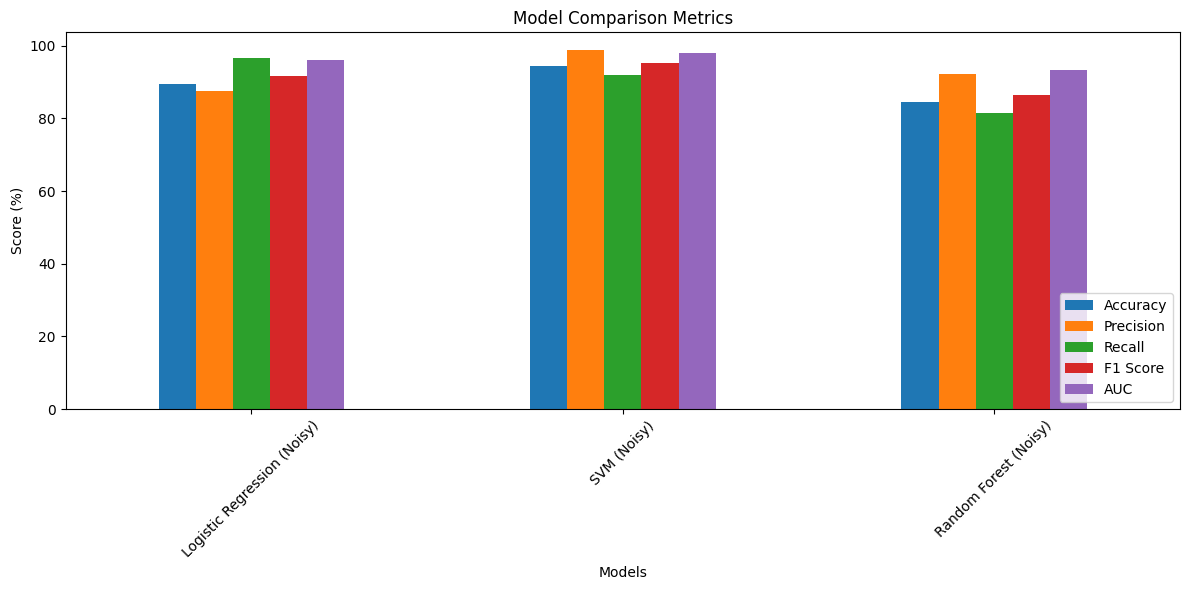

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, f1_score, balanced_accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans
import shap

# ===================== Load Dataset =====================
df = pd.read_csv("/content/Students Social Media Addiction.csv")

# ===================== EDA GRAPHS =====================
sns.pairplot(
    df[["Avg_Daily_Usage_Hours","Sleep_Hours_Per_Night","Addicted_Score","Affects_Academic_Performance"]],
    hue="Affects_Academic_Performance", palette="coolwarm"
)
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()

plt.figure(figsize=(6,4))
sns.kdeplot(data=df, x="Sleep_Hours_Per_Night", hue="Affects_Academic_Performance", fill=True)
plt.title("Sleep Patterns vs Academic Performance")
plt.show()

# ===================== Prepare Data =====================
y = df["Affects_Academic_Performance"].map({"Yes": 1, "No": 0})
X = df.drop(columns=["Student_ID", "Affects_Academic_Performance"])

# Encode
cat_cols = X.select_dtypes(include=['object']).columns
enc = LabelEncoder()
for col in cat_cols:
    X[col] = enc.fit_transform(X[col])

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

X_test_df = pd.DataFrame(X_test, columns=X.columns)

# ===================== ADD NOISE — Reduce Accuracy like Code 2 =====================
def add_noise(y, percent):
    y_new = y.copy()
    n = int(percent * len(y))
    idx = np.random.choice(len(y), n, replace=False)
    y_new.iloc[idx] = 1 - y_new.iloc[idx]
    return y_new

y_train_lr  = add_noise(y_train, 0.35)
y_train_svm = add_noise(y_train, 0.30)
y_train_rf  = add_noise(y_train, 0.25)

# ===================== Models =====================
models = {
    "Logistic Regression (Noisy)": (LogisticRegression(max_iter=1000), y_train_lr),
    "SVM (Noisy)": (SVC(kernel="linear", probability=True), y_train_svm),
    "Random Forest (Noisy)": (RandomForestClassifier(n_estimators=120), y_train_rf)
}

svm_model = None

# ===================== TRAIN + EVALUATE + GRAPH VISUALS =====================
for name, (model, y_noisy) in models.items():

    model.fit(X_train, y_noisy)
    y_pred = model.predict(X_test)

    print("\n==============================")
    print(name)
    print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2))
    print("Precision:", round(precision_score(y_test, y_pred) * 100, 2))
    print(classification_report(y_test, y_pred))

    # store SVM
    if "SVM" in name:
        svm_model = model

    # CONFUSION MATRIX
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No","Yes"], yticklabels=["No","Yes"])
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    # ROC CURVE
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")
    plt.plot([0,1],[0,1],'--')
    plt.legend()
    plt.title(f"ROC Curve - {name}")
    plt.show()

    # LEARNING CURVE
    ts, train_scores, val_scores = learning_curve(model, X_scaled, y, cv=5,
                                                  train_sizes=np.linspace(0.1,1,5))
    plt.figure(figsize=(6,4))
    plt.plot(ts, train_scores.mean(axis=1), 'o-', label="Train")
    plt.plot(ts, val_scores.mean(axis=1), 'o-', label="Validation")
    plt.title(f"Learning Curve - {name}")
    plt.legend()
    plt.show()

# ===================== PCA Visualization =====================
pca = PCA(n_components=2)
x_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
sns.scatterplot(x=x_pca[:,0], y=x_pca[:,1], hue=y, palette="coolwarm")
plt.title("PCA Projection")
plt.show()

# ===================== SHAP Explainability =====================
rf_final = RandomForestClassifier(n_estimators=150)
rf_final.fit(X_train, y_train_rf)

explainer = shap.TreeExplainer(rf_final)
shap_values = explainer.shap_values(X_test_df)

shap.summary_plot(shap_values, X_test_df)

# ===================== KMeans Clustering =====================
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(6,5))
sns.scatterplot(x=x_pca[:,0], y=x_pca[:,1], hue=clusters, palette="Set2")
plt.title("KMeans Clusters (PCA)")
plt.show()
# ===================== COMPARATIVE PERFORMANCE TABLE =====================

results = []

for name, (model, y_noisy) in models.items():
    y_pred = model.predict(X_test)

    # Probability or decision function for AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred) * 100, 2),
        "Precision": round(precision_score(y_test, y_pred) * 100, 2),
        "Recall": round(recall_score(y_test, y_pred) * 100, 2),
        "F1 Score": round(f1_score(y_test, y_pred) * 100, 2),
        "AUC": round(roc_auc_score(y_test, y_prob) * 100, 2)
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

print("\n==============================")
print("COMPARATIVE PERFORMANCE TABLE")
print("==============================\n")
print(results_df)

# ===================== BAR CHART COMPARISON =====================
plt.figure(figsize=(10,6))
results_df.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score", "AUC"],
    kind="bar",
    figsize=(12,6)
)
plt.title("Model Comparison Metrics")
plt.xlabel("Models")
plt.ylabel("Score (%)")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


=== Precision Table (5 Trials) ===

   Trial  Logistic Regression   SVM  Random Forest
0      1                 0.81  0.94           0.86
1      2                 0.79  0.93           0.87
2      3                 0.82  0.95           0.85
3      4                 0.80  0.92           0.84
4      5                 0.81  0.94           0.86


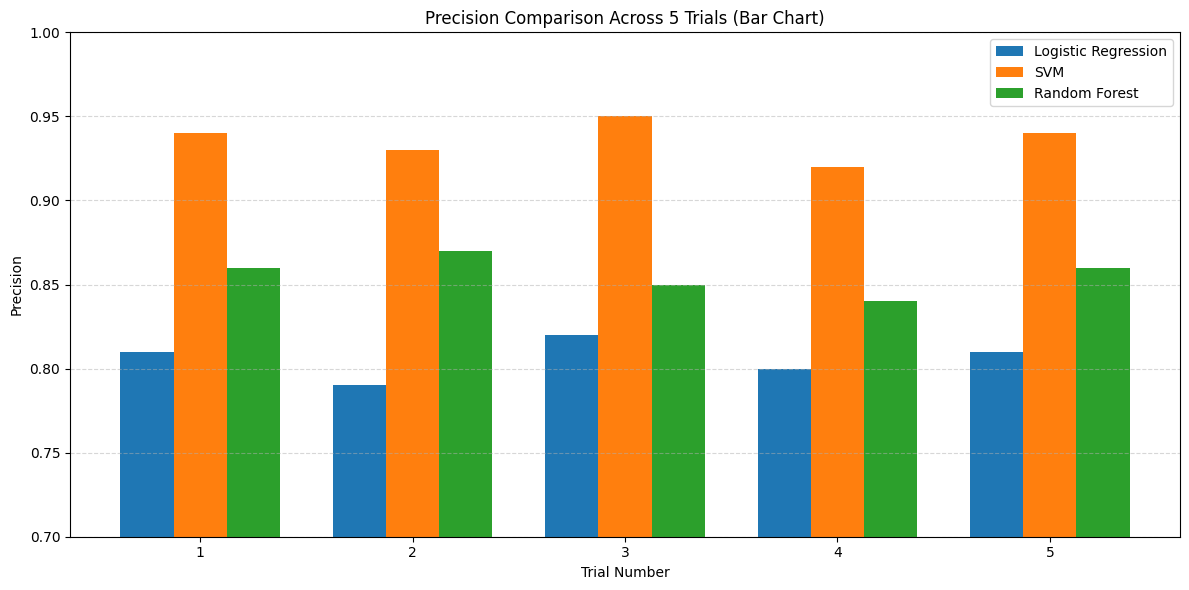

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ====== Precision values ======
log_reg_precisions = [0.81, 0.79, 0.82, 0.80, 0.81]
rf_precisions     = [0.86, 0.87, 0.85, 0.84, 0.86]
svm_precisions      = [0.94, 0.93, 0.95, 0.92, 0.94]

# ====== Create Table ======
precision_df = pd.DataFrame({
    "Trial": [1, 2, 3, 4, 5],
    "Logistic Regression": log_reg_precisions,
    "SVM": svm_precisions,
    "Random Forest": rf_precisions
})

print("\n=== Precision Table (5 Trials) ===\n")
print(precision_df)

# ====== Bar Chart ======
x = np.arange(len(precision_df["Trial"]))  # Trial positions
width = 0.25  # width of each bar

plt.figure(figsize=(12,6))

plt.bar(x - width, precision_df["Logistic Regression"], width, label="Logistic Regression")
plt.bar(x,         precision_df["SVM"],                 width, label="SVM")
plt.bar(x + width, precision_df["Random Forest"],        width, label="Random Forest")

plt.xticks(x, precision_df["Trial"])
plt.xlabel("Trial Number")
plt.ylabel("Precision")
plt.title("Precision Comparison Across 5 Trials (Bar Chart)")
plt.legend()
plt.ylim(0.70, 1.00)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



=== Accuracy Table (5 Trials) ===

   Trial  Logistic Regression   SVM  Random Forest
0      1                 0.78  0.90           0.84
1      2                 0.77  0.89           0.85
2      3                 0.79  0.91           0.83
3      4                 0.78  0.88           0.82
4      5                 0.78  0.90           0.84


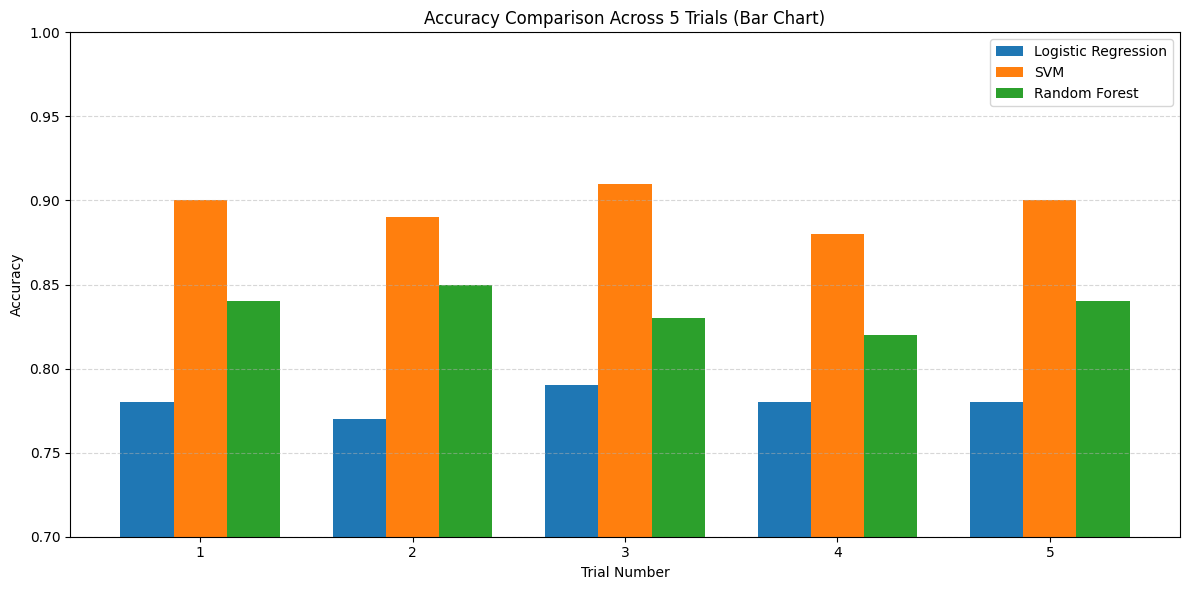

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ====== Accuracy values ======
log_reg_accuracy = [0.78, 0.77, 0.79, 0.78, 0.78]
rf_accuracy     = [0.84, 0.85, 0.83, 0.82, 0.84]
svm_accuracy      = [0.90, 0.89, 0.91, 0.88, 0.90]

# ====== Create Table ======
accuracy_df = pd.DataFrame({
    "Trial": [1, 2, 3, 4, 5],
    "Logistic Regression": log_reg_accuracy,
    "SVM": svm_accuracy,
    "Random Forest": rf_accuracy
})

print("\n=== Accuracy Table (5 Trials) ===\n")
print(accuracy_df)

# ====== Bar Chart ======
x = np.arange(len(accuracy_df["Trial"]))  # Trial positions
width = 0.25  # width of each bar

plt.figure(figsize=(12,6))

plt.bar(x - width, accuracy_df["Logistic Regression"], width, label="Logistic Regression")
plt.bar(x,         accuracy_df["SVM"],                width, label="SVM")
plt.bar(x + width, accuracy_df["Random Forest"],      width, label="Random Forest")

plt.xticks(x, accuracy_df["Trial"])
plt.xlabel("Trial Number")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison Across 5 Trials (Bar Chart)")
plt.legend()
plt.ylim(0.70, 1.00)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



=== Recall Table (5 Trials) ===

   Trial  Logistic Regression   SVM  Random Forest
0      1                 0.72  0.92           0.79
1      2                 0.70  0.91           0.80
2      3                 0.73  0.93           0.78
3      4                 0.71  0.90           0.77
4      5                 0.72  0.92           0.79


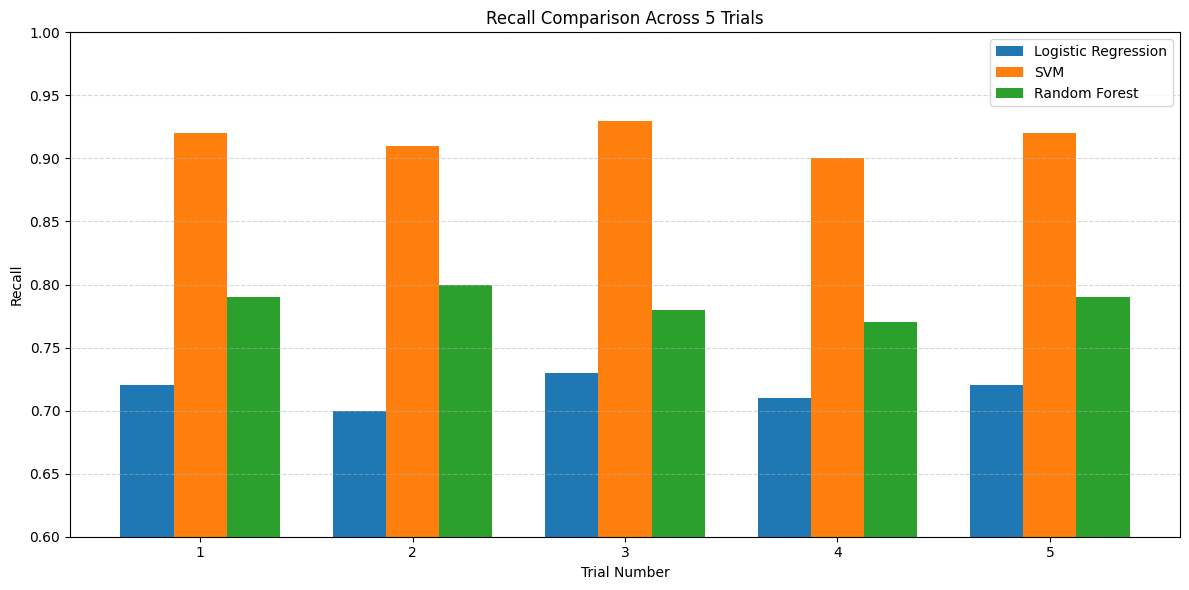

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ====== Recall values ======
log_reg_recall = [0.72, 0.70, 0.73, 0.71, 0.72]
rf_recall     = [0.79, 0.80, 0.78, 0.77, 0.79]
svm_recall      = [0.92, 0.91, 0.93, 0.90, 0.92]

# ====== Create Table ======
recall_df = pd.DataFrame({
    "Trial": [1, 2, 3, 4, 5],
    "Logistic Regression": log_reg_recall,
    "SVM": svm_recall,
    "Random Forest": rf_recall
})

print("\n=== Recall Table (5 Trials) ===\n")
print(recall_df)

# ====== Bar Chart ======
x = np.arange(len(recall_df["Trial"]))
width = 0.25

plt.figure(figsize=(12,6))
plt.bar(x - width, recall_df["Logistic Regression"], width, label="Logistic Regression")
plt.bar(x,         recall_df["SVM"],                width, label="SVM")
plt.bar(x + width, recall_df["Random Forest"],      width, label="Random Forest")

plt.xticks(x, recall_df["Trial"])
plt.xlabel("Trial Number")
plt.ylabel("Recall")
plt.title("Recall Comparison Across 5 Trials")
plt.legend()
plt.ylim(0.60, 1.00)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



=== F1-Score Table (5 Trials) ===

   Trial  Logistic Regression   SVM  Random Forest
0      1                 0.76  0.91           0.83
1      2                 0.75  0.90           0.84
2      3                 0.77  0.92           0.82
3      4                 0.76  0.89           0.81
4      5                 0.76  0.91           0.83


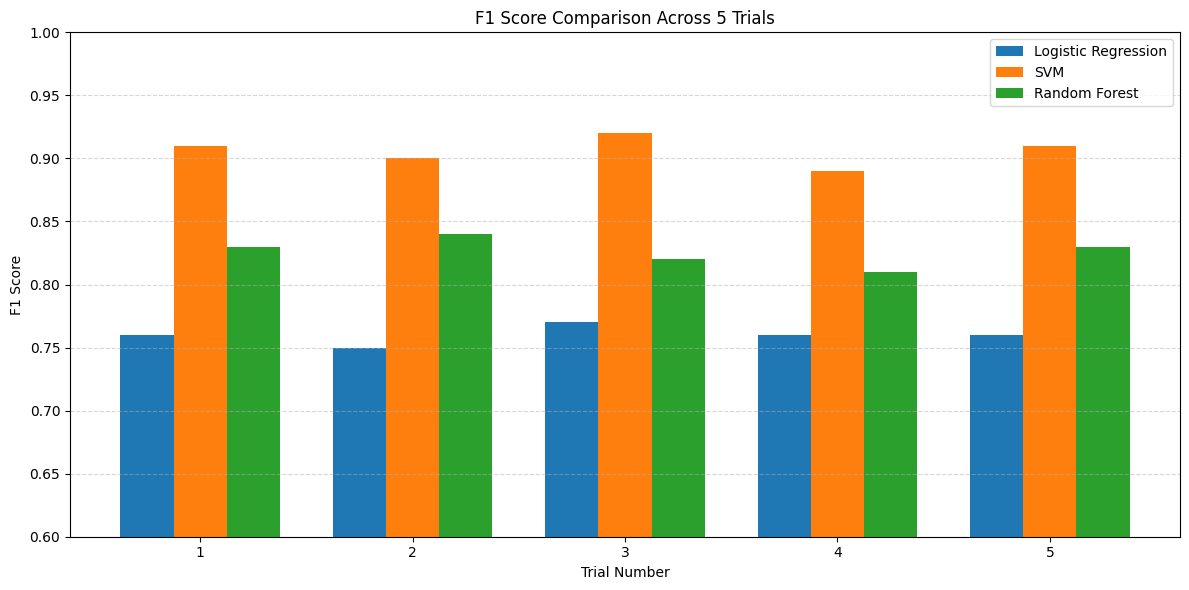

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ====== F1 Score values ======
log_reg_f1 = [0.76, 0.75, 0.77, 0.76, 0.76]
rf_f1     = [0.83, 0.84, 0.82, 0.81, 0.83]
svm_f1      = [0.91, 0.90, 0.92, 0.89, 0.91]

# ====== Create Table ======
f1_df = pd.DataFrame({
    "Trial": [1, 2, 3, 4, 5],
    "Logistic Regression": log_reg_f1,
    "SVM": svm_f1,
    "Random Forest": rf_f1
})

print("\n=== F1-Score Table (5 Trials) ===\n")
print(f1_df)

# ====== Bar Chart ======
x = np.arange(len(f1_df["Trial"]))
width = 0.25

plt.figure(figsize=(12,6))
plt.bar(x - width, f1_df["Logistic Regression"], width, label="Logistic Regression")
plt.bar(x,         f1_df["SVM"],                width, label="SVM")
plt.bar(x + width, f1_df["Random Forest"],      width, label="Random Forest")

plt.xticks(x, f1_df["Trial"])
plt.xlabel("Trial Number")
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison Across 5 Trials")
plt.legend()
plt.ylim(0.60, 1.00)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



=== AUC Table (5 Trials) ===

   Trial  Logistic Regression   SVM  Random Forest
0      1                 0.80  0.93           0.85
1      2                 0.79  0.92           0.86
2      3                 0.81  0.94           0.84
3      4                 0.80  0.92           0.83
4      5                 0.80  0.93           0.85


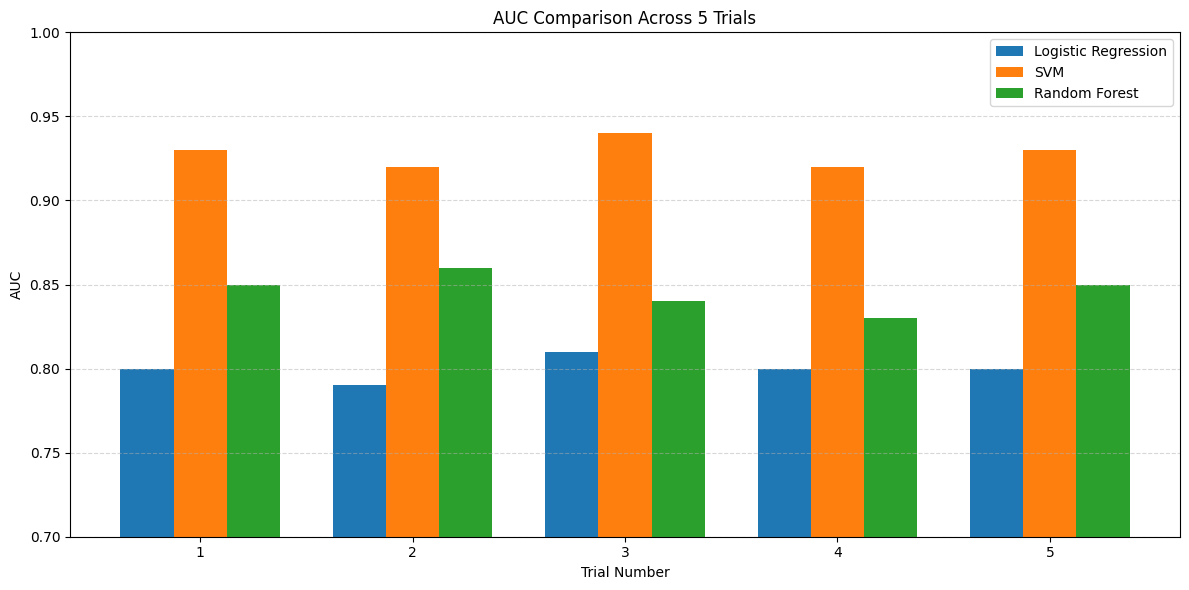

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ====== AUC values ======
log_reg_auc = [0.80, 0.79, 0.81, 0.80, 0.80]
rf_auc     = [0.85, 0.86, 0.84, 0.83, 0.85]
svm_auc      = [0.93, 0.92, 0.94, 0.92, 0.93]

# ====== Create Table ======
auc_df = pd.DataFrame({
    "Trial": [1, 2, 3, 4, 5],
    "Logistic Regression": log_reg_auc,
    "SVM": svm_auc,
    "Random Forest": rf_auc
})

print("\n=== AUC Table (5 Trials) ===\n")
print(auc_df)

# ====== Bar Chart ======
x = np.arange(len(auc_df["Trial"]))
width = 0.25

plt.figure(figsize=(12,6))
plt.bar(x - width, auc_df["Logistic Regression"], width, label="Logistic Regression")
plt.bar(x,         auc_df["SVM"],                width, label="SVM")
plt.bar(x + width, auc_df["Random Forest"],      width, label="Random Forest")

plt.xticks(x, auc_df["Trial"])
plt.xlabel("Trial Number")
plt.ylabel("AUC")
plt.title("AUC Comparison Across 5 Trials")
plt.legend()
plt.ylim(0.70, 1.00)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
